# Modélisation de régression
Dans cette activité, nous allons construire un modèle de régression logistique binomiale. la régression logistique permet d'estimer la probabilité d'un résultat. Pour les professionnels de la science des données, il s'agit d'une compétence précieuse car elle permet de prendre en compte plusieurs variables par rapport à la variable mesurée. Ceci ouvre la voie à des analyses beaucoup plus approfondies et flexibles.

L’objectif de ce projet est de démontrer une connaissance de l’analyse exploratoire des données (EDA) et d’un modèle de régression logistique binomiale.

L'objectif est de construire un modèle de régression logistique binomiale et d'évaluer les performances de ce modèle.

Cette activité comporte trois parties :

Partie 1 : Analyse exploratoire des données et vérification des hypothèses du modèle

Quels sont les objectifs de l'analyse exploratoire des données (EDA) avant la construction d'un modèle de régression logistique binomiale ?
Partie 2 : Modélisation et évaluation

Quelles ressources utilisez-vous pour mener à bien cette étape ?
Partie 3 : Interprétation des résultats du modèle

Quels principaux enseignements ont émergé de vos modèles ?

Quelles recommandations commerciales proposez-vous sur la base des modèles élaborés ?

#**ETAPE PACE**

#**PACE PLAN**

##Tâche 1. Importations et chargement des données
Importez les données et les packages dont vous avez appris qu'ils sont nécessaires à la construction de modèles de régression logistique.


[ ]


In [1]:
# Packages for numerics + dataframes
import pandas as pd
import numpy as np

# Packages for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Packages for Logistic Regression & Confusion Matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, \
recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

Importer l'ensemble de données.

In [2]:
# Load the dataset by running this cell

df = pd.read_csv('/content/drive/MyDrive/PYTHON/coursera/porfolio/waze_dataset.csv')

In [3]:
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


Réfléchissons aux questions de votre document de stratégie PACE pour approfondir votre réflexion sur la phase d'analyse.

À ce stade, considérez la question suivante :

Quels sont les objectifs de l'analyse exploratoire des données (EDA) avant la construction d'un modèle de régression logistique binomiale ?
Les valeurs aberrantes et extrêmes peuvent avoir un impact significatif sur les modèles de régression logistique. Après la visualisation des données, il convient d'établir un plan pour traiter les valeurs aberrantes : suppression de lignes, remplacement des données extrêmes par des données moyennes et/ou suppression des valeurs supérieures à trois écarts-types.

Les activités d'analyse exploratoire des données (EDA) comprennent également l'identification des données manquantes afin d'aider l'analyste à prendre des décisions quant à leur exclusion ou leur inclusion en substituant les valeurs par les moyennes, les médianes et d'autres méthodes similaires de l'ensemble de données.

De plus, il peut être utile de créer des variables en multipliant des variables entre elles ou en calculant le ratio entre deux variables. Par exemple, dans cet ensemble de données, nous pouvons créer une variable drives_sessions_ratio en divisant drives par sessions.


**Tâche 2a. Explorer les données avec l'analyse exploratoire des données (EDA)**

Analyser et découvrir les données, en recherchant des corrélations, des données manquantes, des valeurs aberrantes potentielles et/ou des doublons.

Commençons par shape et info()

In [4]:
print(df.shape)

df.info()

(14999, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


label  manque 700 valeurs dans cette colonne.

Utilisez cette drop()méthode pour supprimer la colonne ID, car nous n'avons pas besoin de cette information pour votre analyse.

In [5]:
df = df.drop('ID', axis=1)

Vérifiez maintenant l'équilibre de classe de la variable dépendante (cible), label

In [6]:
df['label'].value_counts(normalize=True)

,proportion
label,
retained,0.822645
churned,0.177355


Faisons appel describe()aux données.

In [7]:
df.describe()

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


Existe-t-il des variables qui pourraient potentiellement présenter des valeurs aberrantes, si l'on se base uniquement sur les valeurs des quartiles, l'écart type et les valeurs maximales ?

Oui, les colonnes suivantes semblent toutes présenter des valeurs aberrantes :


sessions
drives
total_sessions
total_navigations_fav1
total_navigations_fav2
driven_km_drives
duration_minutes_drives
Toutes ces colonnes présentent des valeurs maximales supérieures de plusieurs écarts-types au 75e percentile. Cela pourrait indiquer la présence de valeurs aberrantes dans ces variables.

**Tâche 2b. Créer des fonctionnalités**

Créez des fonctionnalités susceptibles d'intéresser les parties prenantes et/ou nécessaires pour répondre au scénario/problème commercial.

**km_per_driving_day**
Comme vous l'avez constaté lors d'analyses exploratoires précédentes, le taux de désabonnement est corrélé à la distance parcourue par jour de conduite le mois dernier. Il pourrait être utile de concevoir une fonctionnalité permettant de recueillir cette information.

Créons une nouvelle colonne appelée df, km_per_driving_dayqui représente la distance moyenne parcourue par jour de conduite pour chaque utilisateur.

Appelez la describe()méthode sur la nouvelle colonne

In [8]:
# 1. Create `km_per_driving_day` column
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']

# 2. Call `describe()` on the new column
df['km_per_driving_day'].describe()

,km_per_driving_day
count,1.499900e+04
mean,inf
std,NaN
min,3.022063e+00
25%,1.672804e+02
50%,3.231459e+02
75%,7.579257e+02
max,inf


Notons que certaines valeurs sont infinies. Cela est dû à la présence de zéros dans la driving_dayscolonne. Pandas attribue la valeur infinie aux lignes correspondantes de la nouvelle colonne car la division par zéro n'est pas définie.

Convertissez ces valeurs de l'infini à zéro. Vous pouvez utiliser `0` np.infpour faire référence à une valeur infinie.

Consultez describe()la km_per_driving_daycolonne pour vérifier que cela a fonctionné.

In [9]:
# 1. Convert infinite values to zero
df.loc[df['km_per_driving_day']==np.inf, 'km_per_driving_day'] = 0

# 2. Confirm that it worked
df['km_per_driving_day'].describe()

,km_per_driving_day
count,14999.000000
mean,578.963113
std,1030.094384
min,0.000000
25%,136.238895
50%,272.889272
75%,558.686918
max,15420.234110


**professional_driver**

Créez une nouvelle fonctionnalité binaire professional_driverqui prend la valeur 1 pour les utilisateurs ayant effectué 60 trajets ou plus et ayant conduit pendant plus de 15 jours au cours du dernier mois.

Remarque : L’objectif est de créer une nouvelle fonctionnalité permettant de distinguer les conducteurs professionnels des autres conducteurs. Dans ce contexte, la connaissance du domaine et l’intuition servent à déterminer ces seuils de décision, mais ceux-ci restent arbitraires.



Pour créer cette colonne, utilisez la np.where()fonction. Cette fonction accepte comme arguments :

Une condition
Que renvoyer lorsque la condition est vraie
Que renvoyer lorsque la condition est fauss

Example:
x = [1, 2, 3]
x = np.where(x > 2, 100, 0)
x
array([  0,   0, 100])

In [10]:
# Create `professional_driver` column
df['professional_driver'] = np.where((df['drives'] >= 60) & (df['driving_days'] >= 15), 1, 0)

Effectuons une inspection rapide de la nouvelle variable.

Vérifions le nombre de conducteurs professionnels et non professionnels.

Au sein de chaque catégorie (professionnelle et non professionnelle), calculez le taux de désabonnement.

In [11]:
# 1. Check count of professionals and non-professionals
print(df['professional_driver'].value_counts())

# 2. Check in-class churn rate
df.groupby(['professional_driver'])['label'].value_counts(normalize=True)

professional_driver
0    12405
1     2594
Name: count, dtype: int64


professional_driver  label   
0                    retained    0.801202
                     churned     0.198798
1                    retained    0.924437
                     churned     0.075563
Name: proportion, dtype: float64

Le taux de désabonnement des chauffeurs professionnels est de 7,6 %, tandis que celui des chauffeurs non professionnels atteint 19,9 %. Cette différence pourrait apporter un signal prédictif supplémentaire au modèle.



#**PACE:CONSTRUCTION**

Après l'analyse et l'identification des variables étroitement liées, il est temps de commencer la construction du modèle. Prenez en compte les questions de votre document stratégique PACE pour réfléchir à la phase de construction.

À ce stade, considérons la question suivante :

Pourquoi avoir choisi ces variables X en particulier ?
Dans un premier temps, des colonnes présentant une forte multicolinéarité ont été supprimées. Par la suite, la sélection des variables a pu être affinée en exécutant et réexécutant les modèles afin d'observer les variations de précision, de rappel et d'exactitude.

La sélection initiale des variables s'est appuyée sur l'objectif métier et les enseignements tirés de l'analyse exploratoire des données (EDA) précédente.

**Tâche 3a. Préparation des variables**

Appelez info()le dataframe pour vérifier le type de données de la labelvariable et pour vérifier s'il existe des valeurs manquantes.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   label                    14299 non-null  object 
 1   sessions                 14999 non-null  int64  
 2   drives                   14999 non-null  int64  
 3   total_sessions           14999 non-null  float64
 4   n_days_after_onboarding  14999 non-null  int64  
 5   total_navigations_fav1   14999 non-null  int64  
 6   total_navigations_fav2   14999 non-null  int64  
 7   driven_km_drives         14999 non-null  float64
 8   duration_minutes_drives  14999 non-null  float64
 9   activity_days            14999 non-null  int64  
 10  driving_days             14999 non-null  int64  
 11  device                   14999 non-null  object 
 12  km_per_driving_day       14999 non-null  float64
 13  professional_driver      14999 non-null  int64  
dtypes: float64(4), int64(8

Étant donné que vous savez grâce à l'analyse exploratoire des données (EDA) précédente qu'il n'existe aucune preuve d'une cause non aléatoire des 700 valeurs manquantes dans la labelcolonne, et étant donné que ces observations représentent moins de 5 % des données, utilisez la dropna()méthode pour supprimer les lignes qui ne contiennent pas ces données.

In [13]:
# Drop rows with missing data in `label` column
df = df.dropna(subset=['label'])

***Imputer les valeurs aberrantes***

On souhaite rarement supprimer les valeurs aberrantes, et on ne le fait généralement que s'il existe une raison claire (par exemple, des erreurs typographiques).

Il est parfois possible de remplacer les valeurs aberrantes par la médiane, la moyenne, le 95e percentile, etc.

Auparavant, vous aviez déterminé que sept des variables présentaient des signes évidents de présence de valeurs aberrantes :

sessions
drives
total_sessions
total_navigations_fav1
total_navigations_fav2
driven_km_drives
duration_minutes_drives
Pour cette analyse, imputez les valeurs aberrantes de ces colonnes. Calculez le 95e centile de chaque colonne et remplacez par cette valeur toute valeur qui la dépasse.

In [14]:
# Impute outliers
for column in ['sessions', 'drives', 'total_sessions', 'total_navigations_fav1',
               'total_navigations_fav2', 'driven_km_drives', 'duration_minutes_drives']:
    threshold = df[column].quantile(0.95)
    df.loc[df[column] > threshold, column] = threshold

In [15]:
df.describe()

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_driving_day,professional_driver
count,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000
mean,76.539688,63.964683,183.717304,1751.822505,114.562767,27.187216,3944.558631,1792.911210,15.544653,12.182530,581.942399,0.173998
std,67.243178,55.127927,118.720520,1008.663834,124.378550,36.715302,2218.358258,1224.329759,9.016088,7.833835,1038.254509,0.379121
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000,0.000000,0.000000
25%,23.000000,20.000000,90.457733,878.500000,10.000000,0.000000,2217.319909,840.181344,8.000000,5.000000,136.168003,0.000000
50%,56.000000,48.000000,158.718571,1749.000000,71.000000,9.000000,3496.545617,1479.394387,16.000000,12.000000,273.301012,0.000000
75%,111.000000,93.000000,253.540450,2627.500000,178.000000,43.000000,5299.972162,2466.928876,23.000000,19.000000,558.018761,0.000000
max,243.000000,200.000000,455.439492,3500.000000,422.000000,124.000000,8898.716275,4668.180092,31.000000,30.000000,15420.234110,1.000000


**Encoder les variables catégorielles**

Modifiez le type de données de la labelcolonne pour qu'il soit binaire. Cette modification est nécessaire pour entraîner un modèle de régression logistique.

Attribuer un identifiant 0à tous retainedles utilisateurs.

Attribuer un identifiant 1à tous churnedles utilisateurs.

Enregistrez cette variable afin label2de ne pas écraser la labelvariable d'origine.

Remarque : Il existe plusieurs façons de procéder. Vous pouvez par exemple utiliser la np.where()

In [16]:
# Create binary `label2` column
df['label2'] = np.where(df['label']=='churned', 1, 0)
df[['label', 'label2']].tail()

,label,label2
14994,retained,0
14995,retained,0
14996,retained,0
14997,churned,1
14998,retained,0


**Tâche 3b. Déterminer si les hypothèses ont été vérifiées.**

Voici les hypothèses de la régression logistique :

Observations indépendantes (Cela fait référence à la manière dont les données ont été collectées.)

Aucun cas extrême aberrant

Multicolinéarité faible voire nulle entre les prédicteurs X

Relation linéaire entre X et le logit de y

Pour la première hypothèse, nous pouvons supposer que les observations sont indépendantes pour ce projet.

La deuxième hypothèse a déjà été abordée.

La dernière hypothèse sera vérifiée après la modélisation.

Remarque : En pratique, les hypothèses de modélisation sont souvent violées, et selon les spécificités de votre cas d’utilisation et la gravité de la violation, cela peut ne pas affecter votre modèle du tout ou entraîner un échec du modèle.

Colinéarité

Vérifions la corrélation entre les variables prédictives. Commencez par générer une matrice de corrélation.

In [18]:
# This tells Pandas to ignore any columns that aren't floats or ints
df.corr(method='pearson', numeric_only=True)

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_driving_day,professional_driver,label2
sessions,1.000000,0.996942,0.597189,0.007101,0.001858,0.008536,0.002996,-0.004545,0.025113,0.020294,-0.011569,0.443654,0.034911
drives,0.996942,1.000000,0.595285,0.006940,0.001058,0.009505,0.003445,-0.003889,0.024357,0.019608,-0.010989,0.444425,0.035865
total_sessions,0.597189,0.595285,1.000000,0.006596,0.000187,0.010371,0.001016,-0.000338,0.015755,0.012953,-0.016167,0.254433,0.024568
n_days_after_onboarding,0.007101,0.006940,0.006596,1.000000,-0.002450,-0.004968,-0.004652,-0.010167,-0.009418,-0.007321,0.011764,0.003770,-0.129263
total_navigations_fav1,0.001858,0.001058,0.000187,-0.002450,1.000000,0.002866,-0.007368,0.005646,0.010902,0.010419,-0.000197,-0.000224,0.052322
total_navigations_fav2,0.008536,0.009505,0.010371,-0.004968,0.002866,1.000000,0.003559,-0.003009,-0.004425,0.002000,0.006751,0.007126,0.015032
driven_km_drives,0.002996,0.003445,0.001016,-0.004652,-0.007368,0.003559,1.000000,0.690515,-0.007441,-0.009549,0.344811,-0.000904,0.019767
duration_minutes_drives,-0.004545,-0.003889,-0.000338,-0.010167,0.005646,-0.003009,0.690515,1.000000,-0.007895,-0.009425,0.239627,-0.012128,0.040407
activity_days,0.025113,0.024357,0.015755,-0.009418,0.010902,-0.004425,-0.007441,-0.007895,1.000000,0.947687,-0.397433,0.453825,-0.303851
driving_days,0.020294,0.019608,0.012953,-0.007321,0.010419,0.002000,-0.009549,-0.009425,0.947687,1.000000,-0.407917,0.469776,-0.294259


Maintenant,traçons une carte thermique de corrélation.



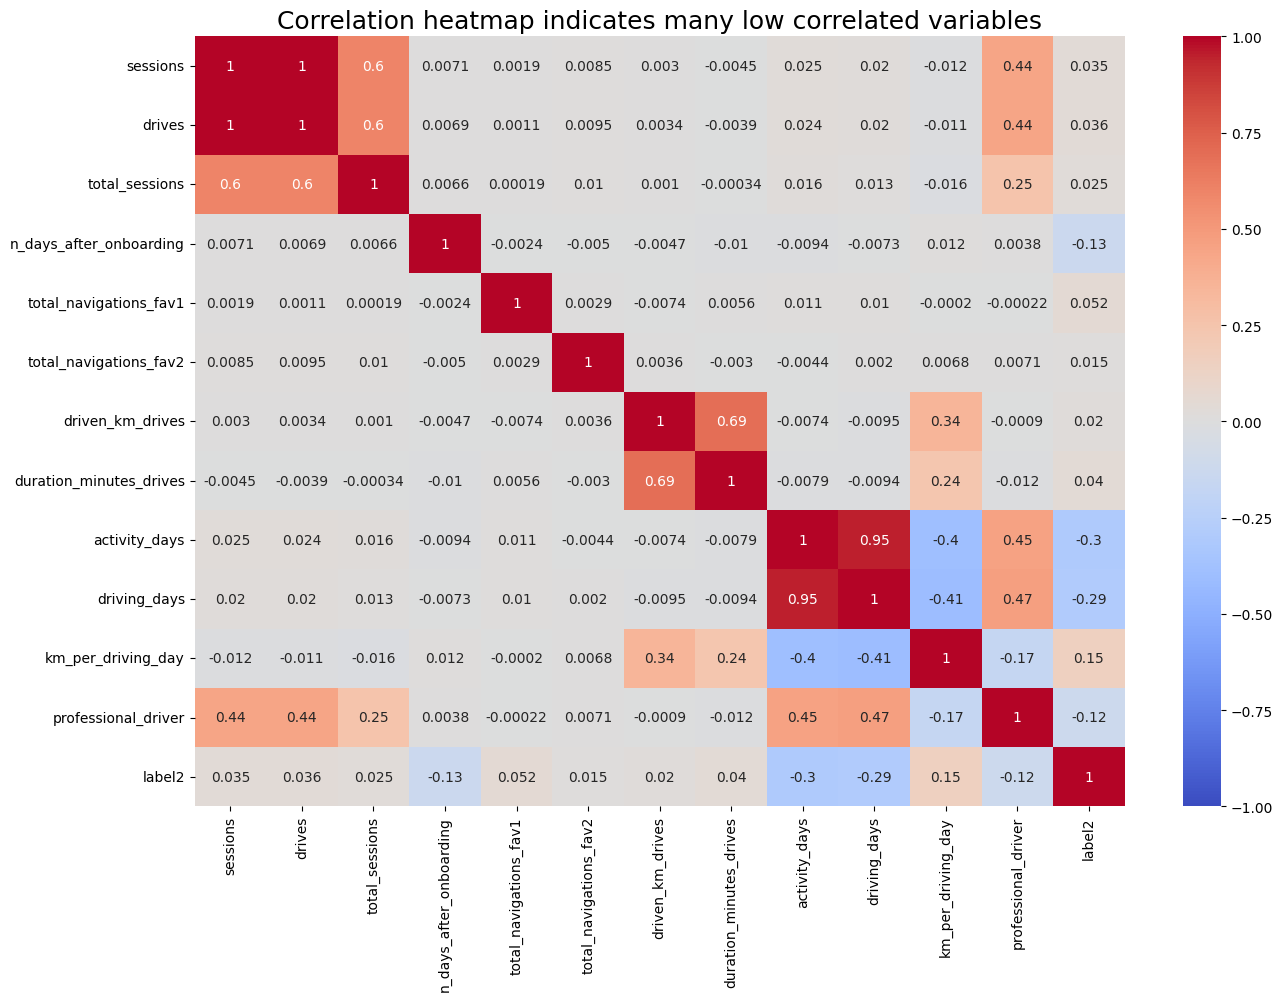

In [20]:
plt.figure(figsize=(15, 10))

# Add numeric_only=True inside the .corr() call
sns.heatmap(df.corr(method='pearson', numeric_only=True),
            vmin=-1, vmax=1,
            annot=True,
            cmap='coolwarm')

plt.title('Correlation heatmap indicates many low correlated variables', fontsize=18)
plt.show()

Si certaines variables explicatives présentent un coefficient de corrélation de Pearson supérieur à 0,7 en valeur absolue , elles sont fortement multicolinéaires. Par conséquent, une seule de ces variables doit être utilisée dans votre modèle.

Remarque : 0,7 est un seuil arbitraire. Certains secteurs peuvent utiliser 0,6, 0,8, etc.

Question : Quelles variables présentent une multicolinéarité entre elles ?

sessionset drives: 1.0

**driving_days` et `activity_days` : 0,95**

**Tâche 3c. Créer des prototypes (si nécessaire)**

Si nous avons sélectionné device cette variable comme variable X, nous devrons créer des variables indicatrices puisque cette variable est catégorielle.

Dans les cas comportant de nombreuses variables catégorielles, vous pouvez utiliser les fonctions intégrées de pandas pd.get_dummies()ou celles de scikit-learn OneHotEncoder().

Remarque : Les variables à nombreuses catégories ne doivent être transformées en variables indicatrices qu’en cas d’absolue nécessité. Chaque catégorie génère un coefficient pour votre modèle, ce qui peut entraîner un surapprentissage.

Comme cet ensemble de données ne comporte plus qu'une seule variable catégorielle ( device), il n'est pas nécessaire d'utiliser l'une de ces fonctions spéciales. Nous pouvons simplement effectuer la transformation directement.

Créond une nouvelle colonne binaire device2 qui encode les appareils des utilisateurs comme suit :

Android->0
iPhone->1

In [21]:
# Create new `device2` variable
df['device2'] = np.where(df['device']=='Android', 0, 1)
df[['device', 'device2']].tail()

,device,device2
14994,iPhone,1
14995,Android,0
14996,iPhone,1
14997,iPhone,1
14998,iPhone,1


T**âche 3D. Construction de maquettes**

Attribuer des variables prédictives et une cible
Pour construire votre modèle, vous devez déterminer quelles variables X vous souhaitez inclure dans votre modèle pour prédire votre cible label2.

Supprimez les variables suivantes et affectez les résultats à X:

label(Ceci est la cible)
label2(Ceci est la cible)
device(Il s'agit de la variable catégorielle non binaire)
sessions(Ceci présentait une forte multicolinéarité)
driving_days(Ceci présentait une forte multicolinéarité)

Remarque : Notons que les variables sessionset driving_days ont été sélectionnées pour être supprimées, plutôt que driveset activity_days. Ceci s’explique par le fait que les variables conservées pour la modélisation présentaient des corrélations légèrement plus fortes avec la variable cible que les variables supprimées.

In [22]:
# Isolate predictor variables
X = df.drop(columns = ['label', 'label2', 'device', 'sessions', 'driving_days'])

Isolez maintenant la variable dépendante (cible). Attribuez-la à une variable appelée y.

In [23]:
 #Isolate target variable
y = df['label2']

Diviser les données
Utilisez la fonction de scikit-learn train_test_split()pour effectuer une division train/test de vos données en utilisant les variables X et y que vous avez attribuées ci-dessus.

Remarque 1 : Il est important d’effectuer un entraînement et un test pour obtenir des prédictions précises. Il est toujours conseillé d’entraîner son modèle sur l’ensemble d’entraînement et de l’évaluer sur l’ensemble de test afin d’éviter toute fuite de données.

Remarque 2 : Étant donné le déséquilibre de la classe cible (82 % d’utilisateurs conservés contre 18 % d’utilisateurs ayant quitté l’entreprise), il est important d’éviter une répartition défavorable qui surreprésenterait ou sous-représenterait la fréquence de la classe minoritaire. Paramétrez la fonction stratifyafin y que la classe minoritaire apparaisse dans les ensembles d’entraînement et de test dans les mêmes proportions que dans l’ensemble de données global.



In [24]:
# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [25]:
# Use .head()
X_train.head()

,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,km_per_driving_day,professional_driver,device2
152,108,186.192746,3116,243,124,8898.716275,4668.180092,24,612.305861,1,1
11899,2,3.487590,794,114,18,3286.545691,1780.902733,5,3286.545691,0,1
10937,139,347.106403,331,4,7,7400.838975,2349.305267,15,616.736581,0,0
669,108,455.439492,2320,11,4,6566.424830,4558.459870,18,410.401552,1,1
8406,10,89.475821,2478,135,0,1271.248661,938.711572,27,74.779333,0,1


Utilisons scikit-learn pour instancier un modèle de régression logistique. Ajoutons l'argument penalty = None.

Il est important de l'ajouter penalty = 'none'car vos prédicteurs ne sont pas mis à l'échelle.

Ajustez le modèle sur X_trainet y_train.

In [27]:
# Change this:
model = LogisticRegression(penalty='none', max_iter=400)

# To this:
model = LogisticRegression(penalty=None, max_iter=400)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=400, penalty=None)

Appelons l' .coef_attribut du modèle pour obtenir les coefficients de chaque variable. Ces coefficients correspondent à l'ordre des variables dans l'ensemble de données. N'oubliez pas que les coefficients représentent la variation du logarithme du rapport de cotes de la variable cible pour chaque augmentation d'une unité de X.

Si nous le souhaitons, créons une série dont l'index correspond aux noms des colonnes et dont les valeurs correspondent aux coefficients de model.coef

In [28]:
pd.Series(model.coef_[0], index=X.columns)

,0
drives,0.001939
total_sessions,0.000360
n_days_after_onboarding,-0.000401
total_navigations_fav1,0.001252
total_navigations_fav2,0.000980
driven_km_drives,-0.000013
duration_minutes_drives,0.000110
activity_days,-0.105260
km_per_driving_day,0.000019
professional_driver,-0.007832


Appelons l'attribut du modèle intercept_pour obtenir l'ordonnée à l'origine du modèle.

In [29]:
model.intercept_

array([-0.05996433])

Vérifions l'hypothèse finale

Vérifions la relation linéaire entre X et le logarithme des cotes estimé (appelé logits) en effectuant un regplot.

Appelons la predict_proba()méthode du modèle pour générer la probabilité de réponse pour chaque échantillon des données d'entraînement. (Les données d'entraînement constituent l'argument de la méthode.) Affectez le résultat à une variable training_probabilities. Nous obtenons ainsi un tableau à deux dimensions où chaque ligne représente un utilisateur X_train. La première colonne indique la probabilité que l'utilisateur ne se désabonne pas, et la seconde, la probabilité qu'il se désabonne.

In [30]:
# Get the predicted probabilities of the training data
training_probabilities = model.predict_proba(X_train)
training_probabilities

array([[0.93739893, 0.06260107],
       [0.6219549 , 0.3780451 ],
       [0.76665913, 0.23334087],
       ...,
       [0.9179998 , 0.0820002 ],
       [0.84880955, 0.15119045],
       [0.93329705, 0.06670295]])

En régression logistique, la relation entre une variable explicative et la variable dépendante n'est pas nécessairement linéaire. Cependant, le logarithme du rapport de cotes (ou logit) de la variable dépendante par rapport à la variable explicative doit l'être. Voici la formule de calcul du logarithme du rapport de cotes, où p représente la probabilité de la réponse :
enregistrer​​il ( p ) = l n (​p1 − p)


Créons un dataframe appelé logit_data qui est une copie de df.

Créos une nouvelle colonne logitdans le logit_datadataframe. Les données de cette colonne doivent représenter le logit de chaque utilisateur.

In [31]:
# 1. Copy the `X_train` dataframe and assign to `logit_data`
logit_data = X_train.copy()

# 2. Create a new `logit` column in the `logit_data` df
logit_data['logit'] = [np.log(prob[1] / prob[0]) for prob in training_probabilities]

Traçons un graphique régulier où l'axe des x représente une variable indépendante et l'axe des y représente le logarithme des cotes des probabilités prédites.

Dans une analyse exhaustive, ce graphique serait tracé pour chaque variable prédictive continue ou discrète. Ici, nous n'en montrons qu'une seule activity_days.

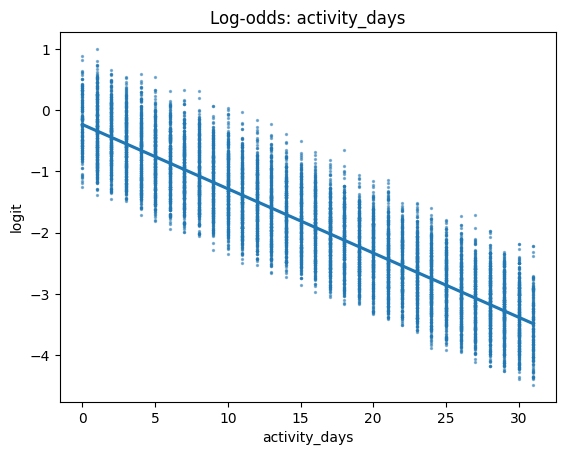

In [32]:
# Plot regplot of `activity_days` log-odds
sns.regplot(x='activity_days', y='logit', data=logit_data, scatter_kws={'s': 2, 'alpha': 0.5})
plt.title('Log-odds: activity_days');

#**PACE:EXÉCUTION**

**Tâche 4a. Résultats et évaluation**

Si les hypothèses logistiques sont vérifiées, les résultats du modèle peuvent être interprétés de manière appropriée.

Utilisez le bloc de code ci-dessous pour effectuer des prédictions sur les données de test.

In [33]:
# Generate predictions on X_test
y_preds = model.predict(X_test)

Utilisons maintenant la score()méthode sur le modèle avec X_test`and` et y_test`or` comme arguments. La précision par défaut dans scikit-learn est `accuracy` . Quelle est la précision de votre modèle ?

Question : La précision est-elle la meilleure mesure à utiliser pour évaluer ce modèle ?

In [34]:
# Score the model (accuracy) on the test data
model.score(X_test, y_test)

0.8243356643356643

**Tâche 4b. Présenter les résultats à l'aide d'une matrice de confusion.**

Utilisons la confusion_matrixfonction pour obtenir une matrice de confusion. Utilisez y_testet y_predscomme arguments.

In [35]:
cm = confusion_matrix(y_test, y_preds)

Ensuite, utilisons la ConfusionMatrixDisplay()fonction pour afficher la matrice de confusion de la cellule ci-dessus, en lui passant comme argument la matrice de confusion que vous venez de créer.

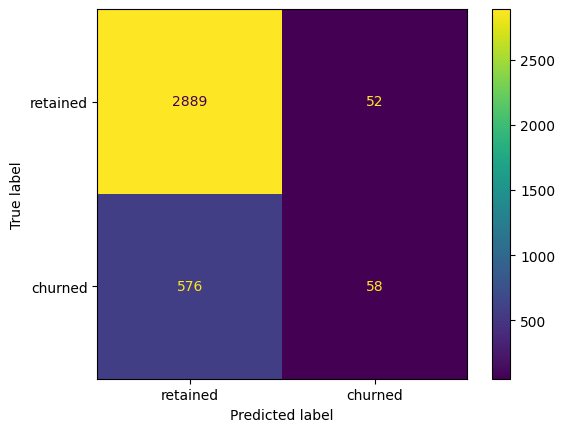

In [36]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['retained', 'churned'],
                              )
disp.plot();

Nous pouvons utiliser la matrice de confusion pour calculer manuellement la précision et le rappel. Nous pouvons également utiliser la fonction de scikit-learn classification_report()pour générer un tableau à partir de y_testces valeurs y_preds.

In [37]:
# Calculate precision manually
precision = cm[1,1] / (cm[0, 1] + cm[1, 1])
precision

np.float64(0.5272727272727272)

In [38]:
# Calculate recall manually
recall = cm[1,1] / (cm[1, 0] + cm[1, 1])
recall

np.float64(0.0914826498422713)

In [39]:
# Create a classification report
target_labels = ['retained', 'churned']
print(classification_report(y_test, y_preds, target_names=target_labels))

              precision    recall  f1-score   support

    retained       0.83      0.98      0.90      2941
     churned       0.53      0.09      0.16       634

    accuracy                           0.82      3575
   macro avg       0.68      0.54      0.53      3575
weighted avg       0.78      0.82      0.77      3575



Remarque:Le modèle présente une précision médiocre et un rappel très faible, ce qui signifie qu’il génère de nombreuses prédictions faussement négatives et ne parvient pas à identifier les utilisateurs susceptibles de se désabonner

Générez un graphique à barres des coefficients du modèle pour une représentation visuelle de l'importance des caractéristiques du modèle.

In [40]:
# Create a list of (column_name, coefficient) tuples
feature_importance = list(zip(X_train.columns, model.coef_[0]))

# Sort the list by coefficient value
feature_importance = sorted(feature_importance, key=lambda x: x[1], reverse=True)
feature_importance

[('device2', np.float64(0.023549302667843983)),
 ('drives', np.float64(0.001939387615349039)),
 ('total_navigations_fav1', np.float64(0.0012522647403906623)),
 ('total_navigations_fav2', np.float64(0.0009801818861498075)),
 ('total_sessions', np.float64(0.00036046643631504756)),
 ('duration_minutes_drives', np.float64(0.00011002335867456627)),
 ('km_per_driving_day', np.float64(1.9464332930663533e-05)),
 ('driven_km_drives', np.float64(-1.2834183126530495e-05)),
 ('n_days_after_onboarding', np.float64(-0.0004010144993282301)),
 ('professional_driver', np.float64(-0.007832476831167487)),
 ('activity_days', np.float64(-0.10526042145649211))]

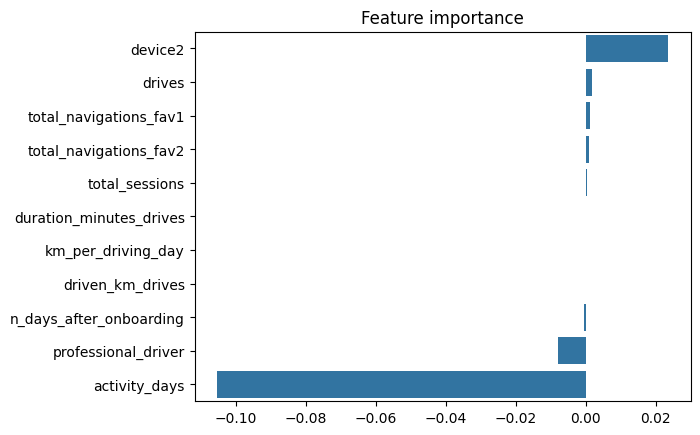

In [41]:
# Plot the feature importances
import seaborn as sns
sns.barplot(x=[x[1] for x in feature_importance],
            y=[x[0] for x in feature_importance],
            orient='h')
plt.title('Feature importance');

**Tâche 4c. Conclusion**

Maintenant que nous avons créé notre modèle de régression, l'étape suivante consiste à partager nos résultats avec l'équipe dirigeante de Waze. Lors de la rédaction de notre synthèse, posons-nous les questions suivantes : quels sont les points clés à partager avec l'équipe et quelles informations sont les plus pertinentes pour le projet sur le taux de désabonnement des utilisateurs ?

Questions :

Quelle variable a le plus influencé la prédiction du modèle ? De quelle manière ? Est-ce surprenant ?
activity_days était de loin la caractéristique la plus importante du modèle.

Elle présentait une corrélation négative avec le taux de désabonnement des utilisateurs. Ce résultat n'était pas surprenant, car cette variable était très fortement corrélée avec driving_days, dont l'analyse exploratoire des données (EDA) avait révélé une corrélation négative avec le taux de désabonnement.

Y avait-il des variables dont nous nous attendiez à ce qu'elles soient de meilleurs prédicteurs qu'elles ne l'ont été ?
Oui. Lors des précédentes analyses exploratoires, le taux de désabonnement des utilisateurs augmentait avec les valeurs de cette variable km_per_driving_day. La carte thermique de corrélation présentée ici révèle que cette variable présente la corrélation positive la plus forte avec le taux de désabonnement parmi toutes les variables prédictives, et de loin. Dans le modèle, il s'agit de la deuxième variable la moins importante.

Recommandation à Waze d'utiliser ce modèle ? Pourquoi ou pourquoi pas ?
Cela dépend. À quoi servirait le modèle ? S'il est destiné à orienter des décisions commerciales importantes, alors non. Le modèle n'est pas suffisamment performant en termes de prédiction, comme le montre son faible score de rappel. En revanche, s'il sert uniquement à guider des recherches exploratoires ultérieures, il peut s'avérer utile.

Ce que nous pourrions faire pour améliorer ce modèle
De nouvelles fonctionnalités pourraient être conçues pour tenter d'améliorer la prédiction, comme c'est souvent le cas lorsqu'on possède des connaissances du domaine. Dans le cas de ce modèle, l'une des fonctionnalités conçues ( professional_driver) était le troisième prédicteur le plus performant. Il pourrait également être utile de normaliser les variables prédictives et/ou de reconstruire le modèle avec différentes combinaisons de variables prédictives afin de réduire le bruit provenant des fonctionnalités non prédictives.

Les fonctionnalités supplémentaires  pour améliorer le modèle
Il serait utile de disposer d'informations détaillées sur les trajets de chaque utilisateur (durée, localisation, etc.). Des données plus précises sur l'interaction des utilisateurs avec l'application seraient également pertinentes. Par exemple, à quelle fréquence signalent-ils ou confirment-ils les alertes de danger sur la route ? Enfin, le nombre mensuel de lieux de départ et d'arrivée uniques enregistrés par chaque conducteur serait un atout.